In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import gc
from tqdm import tqdm
from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedRNN
from bioplnn.utils import (
    initialize_dataloader,
    initialize_scheduler,
    manual_seed,
)
import pickle
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300

checkpoint_path = "./train/checkpoints/"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)
        self.gap   = nn.AdaptiveAvgPool2d(1)     # <- NEW
        self.fc1   = nn.Linear(128, 512)          # <- 64 channels only
        self.fc2   = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.gap(x)                          # [B, 64, 1, 1]
        x = torch.flatten(x, 1)                  # [B, 64]
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
    
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""

    full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    model_cfg = full_cfg["model_config"]
    if "num_steps" in full_cfg:
        num_steps = full_cfg["num_steps"]
    else:
        num_steps = 20

    if full_cfg["model_type"] == "cnn":
        model = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
        classifier = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
    else:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)


        # ——— Load checkpoint & weights ———
    try:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
    except:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

    try:
        state_dict = state_dict["model_state"]
    except:
        pass

    model.load_state_dict(prepare_rnn_weights(state_dict))
    classifier.load_state_dict(state_dict)

    return model, classifier, num_steps, full_cfg

In [36]:
# wandb_name = "fancy-silence-24"
# checkpoint = 370

wandb_name = "glowing-deluge-31"
checkpoint = 330

wandb_name, checkpoint = "rosy-morning-40", 390 # new jawn

# ——— Load model config & instantiate ———
model, classifier, num_steps, cfg = load_model_and_config(wandb_name, checkpoint_path)

model.eval()
model.to(device)

classifier.eval()
classifier.to(device)

/tmp/ipykernel_1242411/1340032787.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

SpatiallyEmbeddedClassifier(
  (rnn): SpatiallyEmbeddedRNN(
    (areas): ModuleList(
      (0): SpatiallyEmbeddedArea(
        (out_nonlinearity): Identity()
        (neuron_type_nonlinearity): ModuleList(
          (0-1): 2 x ReLU()
        )
        (convs): ModuleDict(
          (0->0): Sequential(
            (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): Identity()
          )
          (0->1): Sequential(
            (0): Conv2d(1, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): Identity()
          )
          (1->0): Sequential(
            (0): Conv2dRectify(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): Identity()
          )
          (1->1): Sequential(
            (0): Conv2dRectify(8, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): Identity()
          )
          (2->0): Sequential(
            (0): Conv2dRectify(4, 8, kernel_size=(5, 5), stride=(1, 1), padding

In [27]:
n_frames = 40
resolution = (128, 128)
correlation = (0.25,0.75)
max_speed = 1
samples_per_epoch = 20

In [ ]:
n_frames_list = [80]
# n_frames_list = np.array([int(40 * 0.1), int(40 * 0.3), 20, int(40 * 0.7), 40]) #- 1
coherences = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
# coherences = [0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 0.9]
all_accuracies = []
max_speeds = [1, 2, 3, 4, 5]
max_speed = 1

for correlation in tqdm(coherences):
    accuracies = []
    for n_frames in n_frames_list:
        data_loader, test_loader = initialize_dataloader(
                seed=10, dataset="correlated_dots",
                resolution=resolution, n_frames=n_frames, correlation=correlation, max_speed=max_speed, samples_per_epoch=256*6,
                batch_size=256)
                
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for x, labels in data_loader:
                x = x.to(device)

                if cfg["model_type"] == "cnn":
                    x = x[:, :, 0, :, :]
                    if x.shape[1] < 40:
                        #fill with zeros
                        x = torch.cat([x, torch.zeros(x.shape[0], 40 - x.shape[1], x.shape[2], x.shape[3]).to(device)], dim=1)
                    logits = classifier(x).detach().cpu()
                else:
                    logits = classifier(x, num_steps=num_steps).detach().cpu()

                if labels.ndim == 2 and labels.size(1) == 1:
                    labels = labels.squeeze(1)       # [N, 1] -> [N]
                elif labels.ndim != 1:
                    raise ValueError(f"Expected labels shape [N] or [N,1], got {tuple(labels.shape)}")

                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracies.append(correct / total)
        torch.cuda.empty_cache()
        gc.collect()
    all_accuracies.append(accuracies)

100%|██████████| 10/10 [05:37<00:00, 33.76s/it]


In [35]:
all_cnn_accuracies = all_accuracies

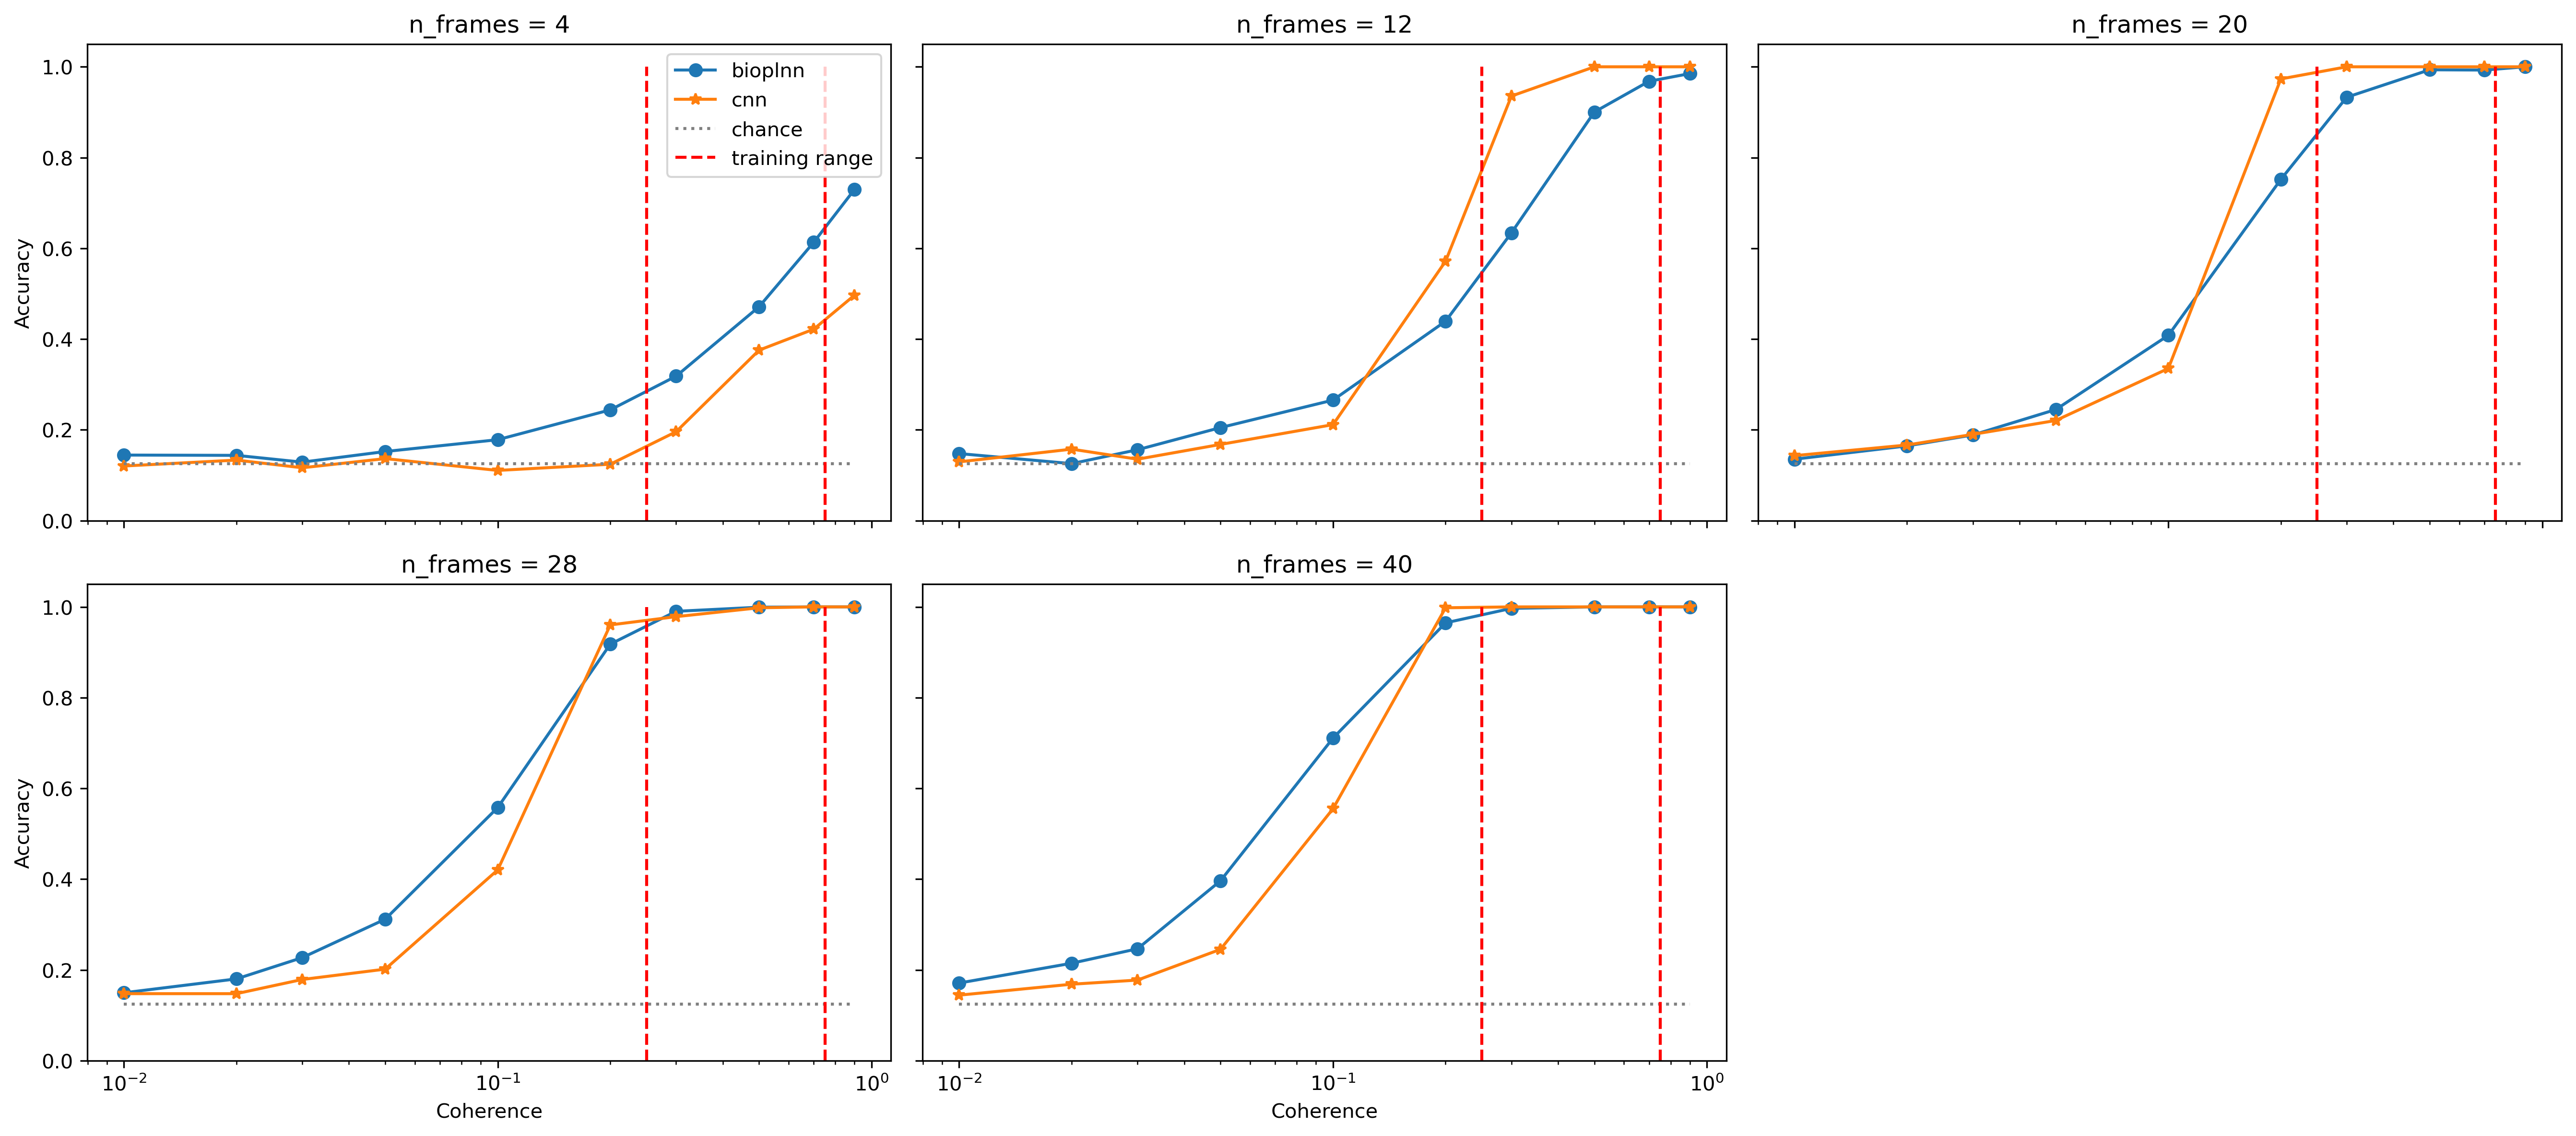

In [47]:
import matplotlib as mpl

# Use a professional color palette
color_map = plt.get_cmap("tab10")  # or try "Set2", "tab20", "Dark2", etc.

n_rows = int(np.ceil(len(n_frames_list) / 3))
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

mpl.rcParams.update({'axes.prop_cycle': mpl.cycler(color=[color_map(i) for i in range(len(n_frames_list))])})

for i, n_frames in enumerate(n_frames_list):
    ax = axes[i]
    ax.plot(coherences, np.array(all_accuracies)[:, i], marker="o", label="bioplnn")
    ax.plot(coherences, np.array(all_cnn_accuracies)[:, i], marker="*", label="cnn")
    ax.hlines(1/8, min(coherences), max(coherences), colors='gray', linestyles='dotted', label="chance")
    ax.vlines([0.25, 0.75], ymin=0, ymax=1, colors='red', linestyles='dashed', label="training range")
    ax.set_xscale("log")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"n_frames = {n_frames}")
    if i % n_cols == 0:
        ax.set_ylabel("Accuracy")
    if i >= (n_rows - 1) * n_cols:
        ax.set_xlabel("Coherence")
    if i == 0:
        ax.legend()

# Hide any unused subplots
for j in range(len(n_frames_list), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [60]:
len(all_accuracies)

20

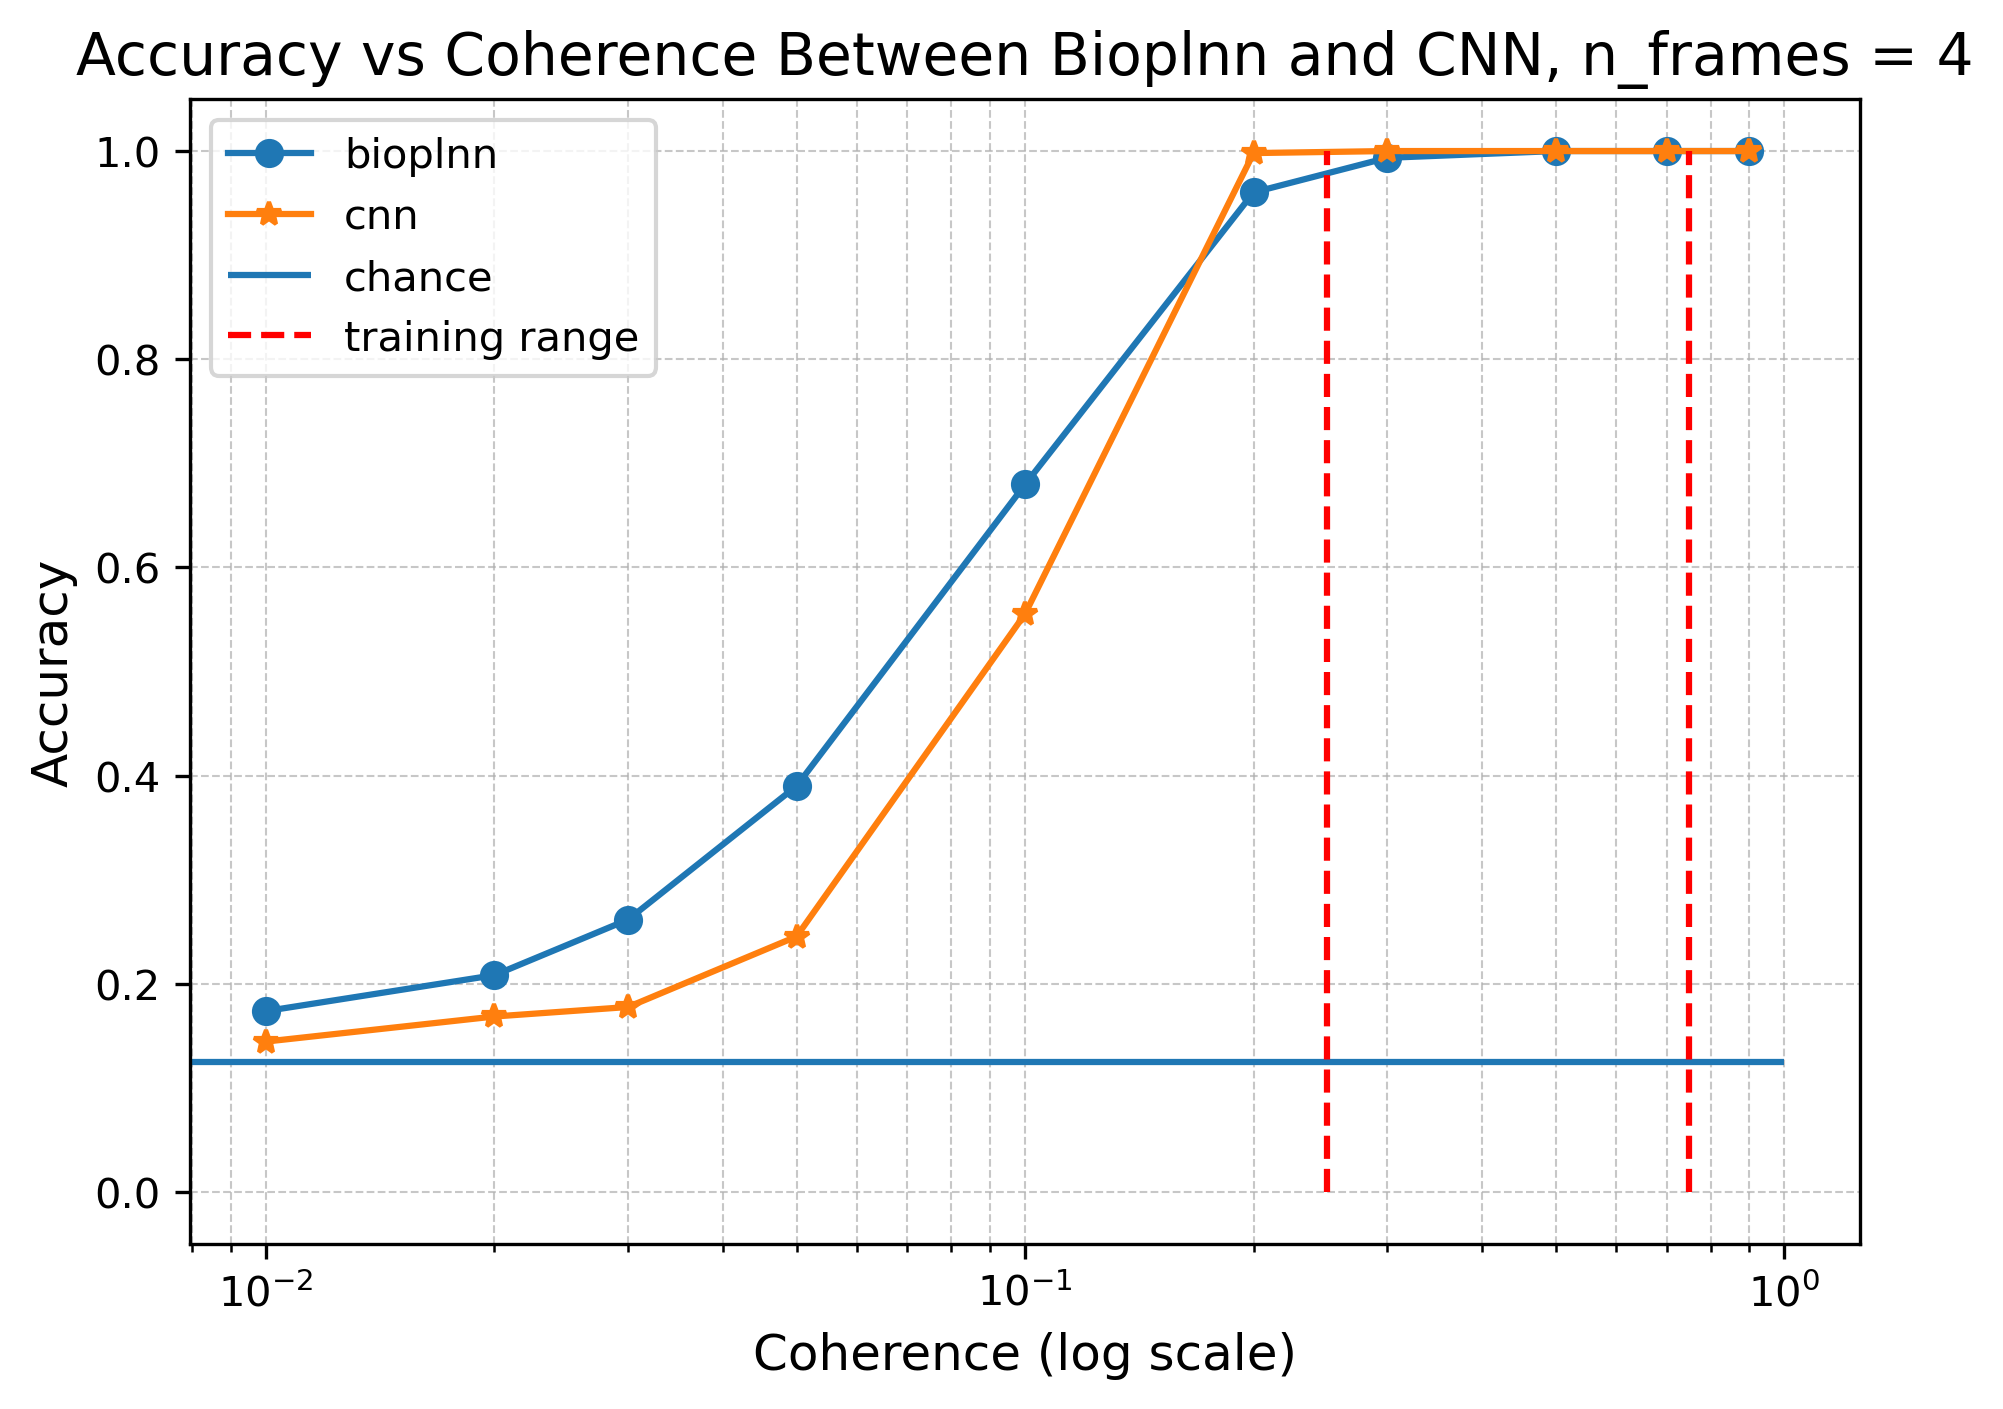

In [59]:
#plot just n_frames = 40
plt.plot(coherences, np.array(all_accuracies[10:]), marker="o", label="bioplnn")
plt.plot(coherences, np.array(all_cnn_accuracies)[:, 4], marker="*", label="cnn")
plt.legend()
plt.hlines(1/8, 0, 1, label="chance")
plt.vlines([0.25, 0.75], ymin=0, ymax=1, colors='red', linestyles='dashed', label="training range")
plt.xscale("log")
plt.xlabel("Coherence (log scale)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Accuracy vs Coherence Between Bioplnn and CNN, n_frames = 4", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
timestep_idxs

[3, 11, 15, 27, 39, 79]

7
7
7
7
7
7
7
7
7
7
7
7


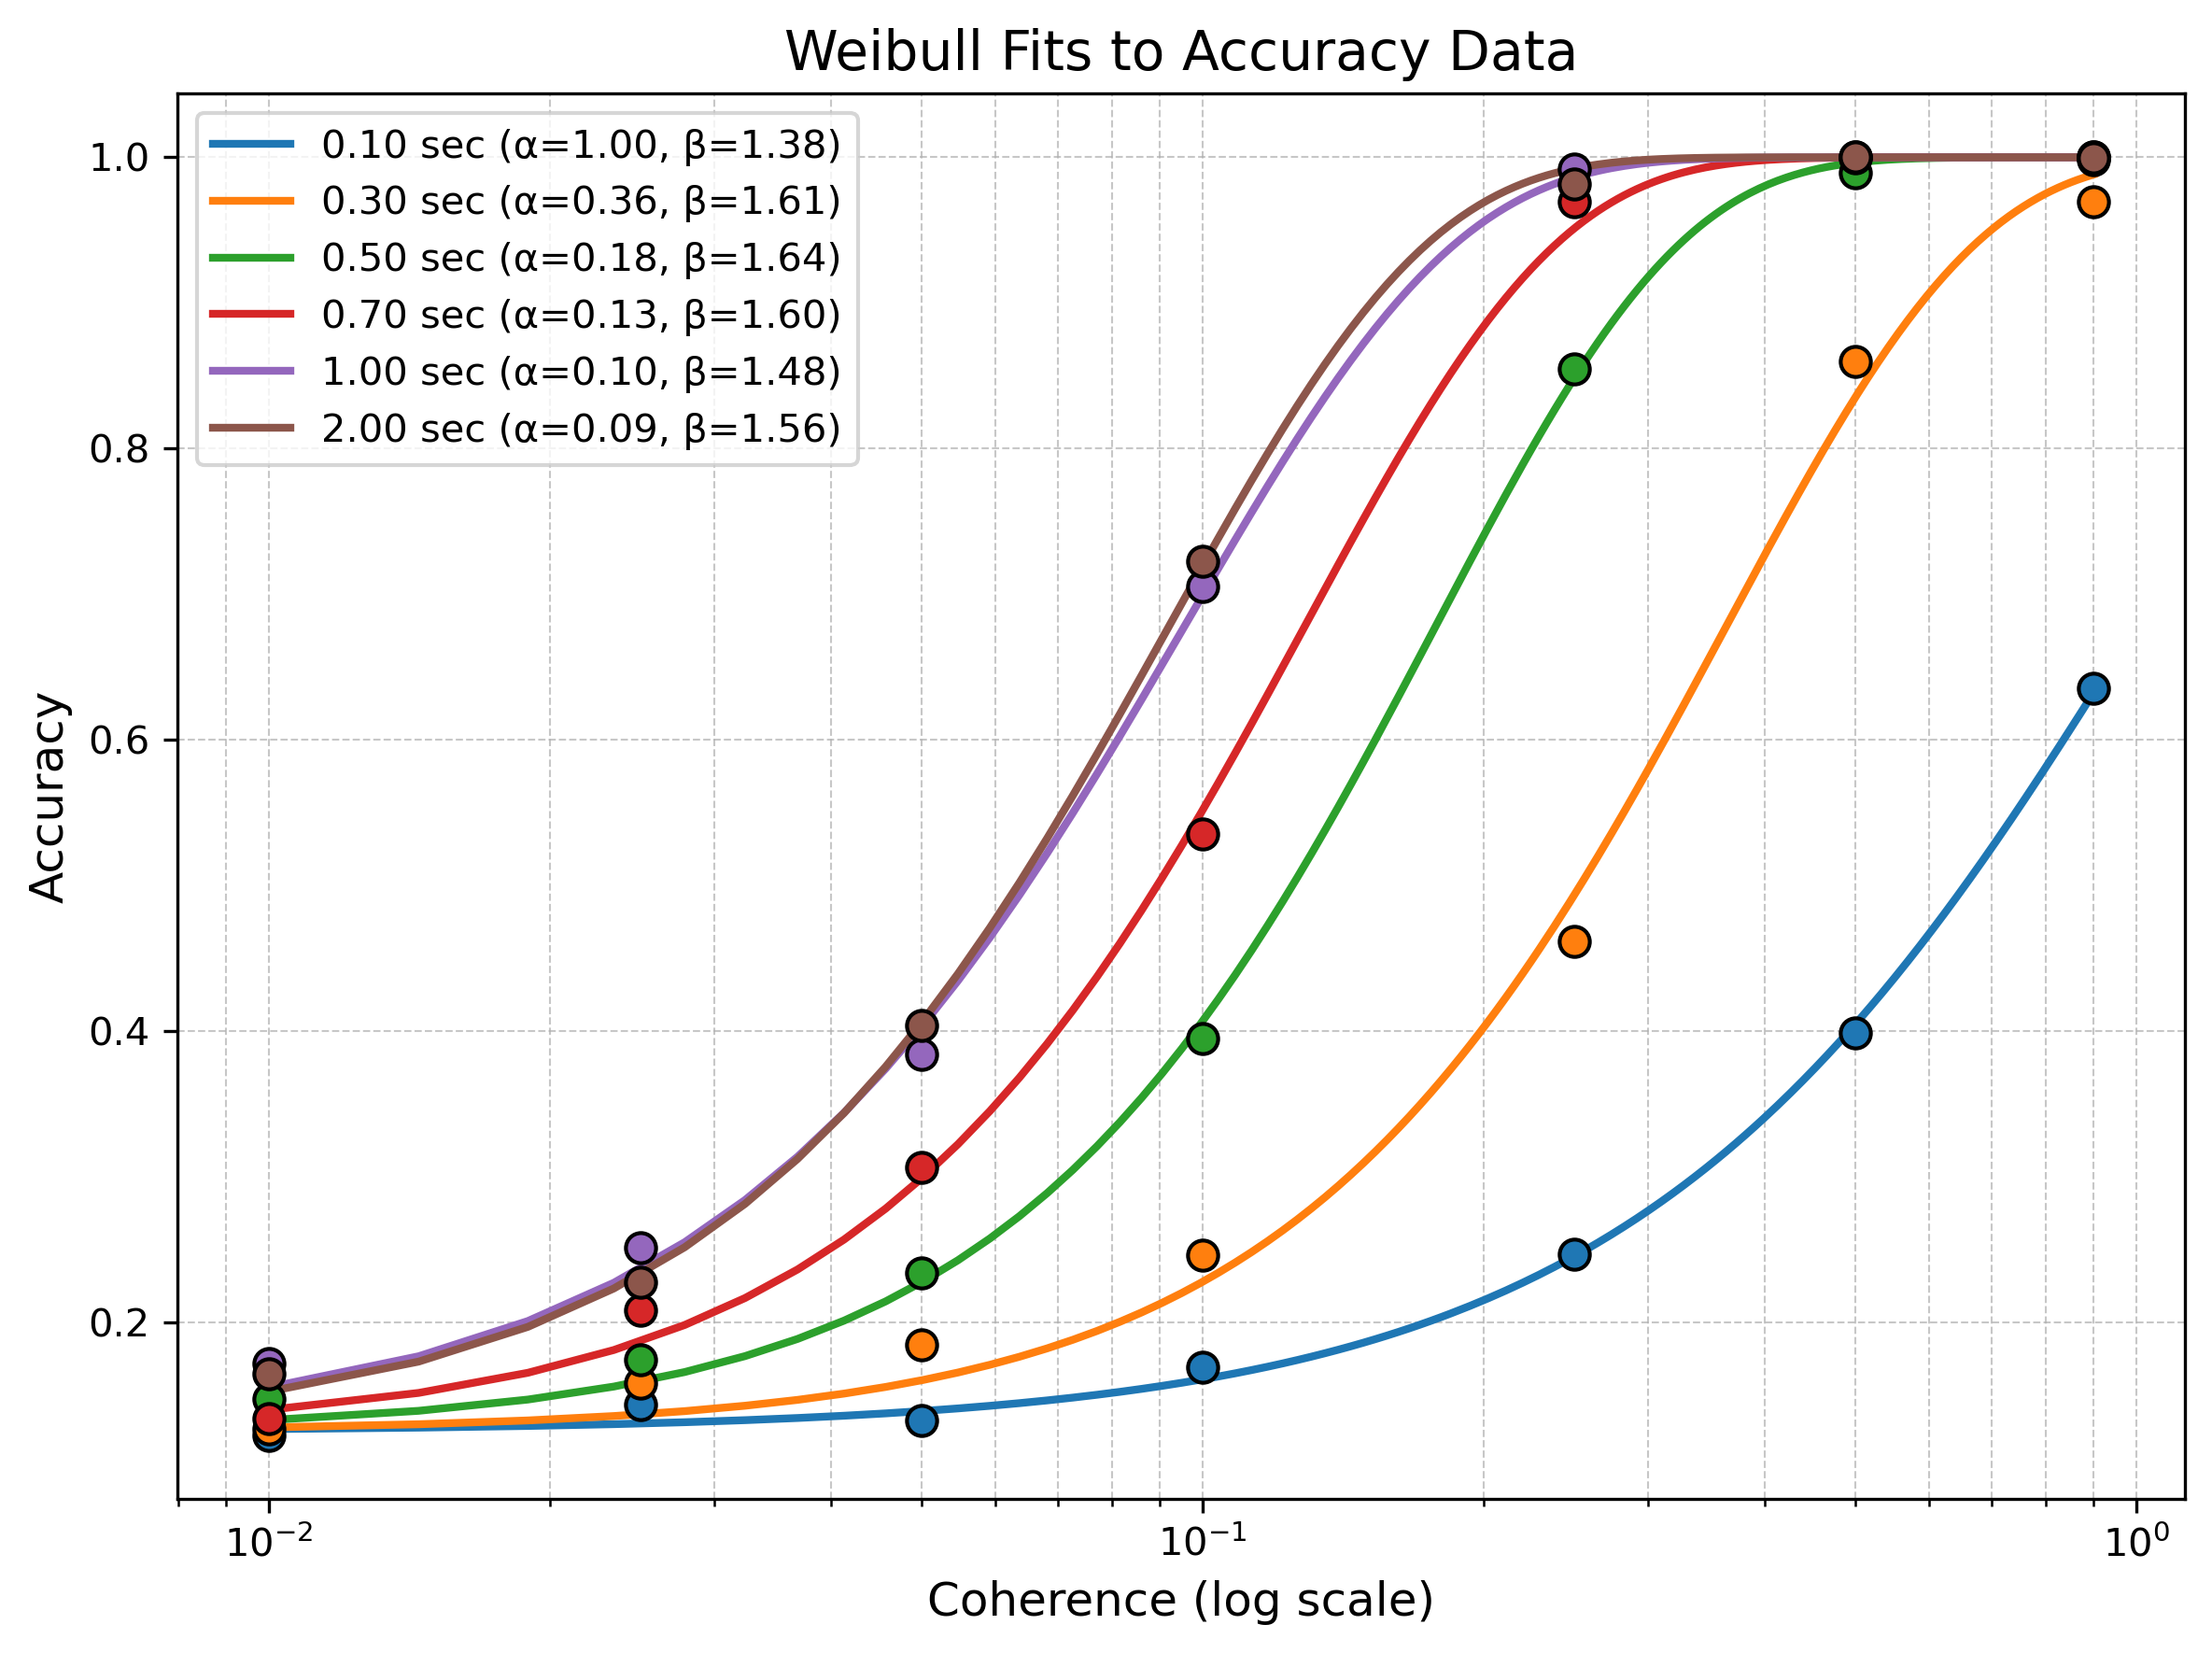

{np.int64(0): (np.float64(0.9978133708859558), np.float64(1.381493126826551)),
 np.int64(1): (np.float64(0.36386605359583923),
  np.float64(1.6112603480749779)),
 np.int64(2): (np.float64(0.17771701311416865),
  np.float64(1.6439356810915298)),
 np.int64(3): (np.float64(0.1287124439896438), np.float64(1.5957272268881397)),
 np.int64(4): (np.float64(0.09567912429401562),
  np.float64(1.4833999842618777)),
 np.int64(5): (np.float64(0.09209113718198687),
  np.float64(1.5552010017988878))}

In [12]:
from scipy.optimize import curve_fit
import matplotlib as mpl

# Use a professional color palette
color_map = plt.get_cmap("tab10")  # or try "Set2", "tab20", "Dark2", etc.

# Example Weibull function
def weibull_func(x, alpha, beta):
    return 1 - (7/8) * np.exp(-((x / alpha) ** beta))

# Given arrays
timestep_idxs = [3, 11, 15, 27, 39, 79]
timestep_idxs = np.arange(len(n_frames_list))
# coherences = np.array([0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9])
# coherences = np.array([0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 0.9])

fit_params = {}

all_accuracies = np.array(all_accuracies)

plt.figure(figsize=(8, 6))
mpl.rcParams.update({'axes.prop_cycle': mpl.cycler(color=[color_map(i) for i in range(len(timestep_idxs))])})

for idx, tidx in enumerate(timestep_idxs):
    accuracies = all_accuracies[:, tidx]
    print(len(accuracies))
    print(len(coherences))

    # Fit Weibull curve
    try:
        popt, _ = curve_fit(weibull_func, coherences, accuracies, p0=[0.2, 2.0], bounds=(0, np.inf))
        alpha, beta = popt
    except RuntimeError:
        alpha, beta = np.nan, np.nan
    
    fit_params[tidx] = (alpha, beta)

    # Plot fitted curve
    x_fit = np.linspace(min(coherences), max(coherences), 200)
    y_fit = weibull_func(x_fit, alpha, beta)

    # Assign color from the palette
    color = color_map(idx % color_map.N)

    # Plot fitted curve first (line)
    line, = plt.plot(x_fit, y_fit, "-", label=f"{(n_frames_list[tidx]+1)/40:.2f} sec (α={alpha:.2f}, β={beta:.2f})", color=color, linewidth=2)

    # Use the same color for the scatter points, with a professional marker
    plt.scatter(coherences, accuracies, color=color, marker="o", edgecolor="k", s=60, zorder=3)

plt.xscale("log")
plt.xlabel("Coherence (log scale)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(frameon=True, fontsize=10, loc="best")
plt.title("Weibull Fits to Accuracy Data", fontsize=14)
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

fit_params

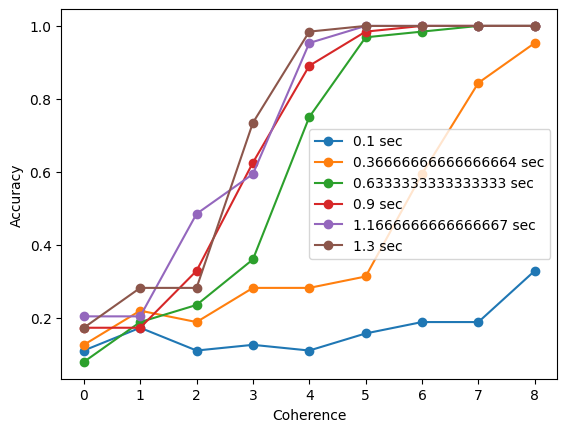

In [13]:
timestep_idxs = [3, 11, 19, 27, 35, 39]
coherences = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
for tidx in timestep_idxs:
    accuracies = all_accuracies[:, tidx]
    plt.plot(np.arange(len(all_accuracies)), accuracies, label=f"{tidx/30} sec", marker="o")
    plt.xlabel("Coherence")
    plt.ylabel("Accuracy")
plt.legend()
plt.show()

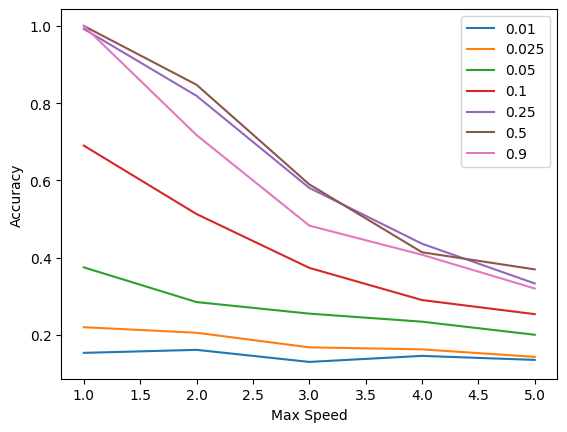

In [92]:
indices = np.arange(2, 48, 4)
for corridx, accuracies in enumerate(all_cnn_accuracies2):
    plt.plot(max_speeds, np.array(accuracies), label=correlations[corridx])
    plt.xlabel("Max Speed")
    plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [5]:
direction_names = {
            0: "E",
            1: "W",
            2: "N",
            3: "S",
            4: "NE",
            5: "NW",
            6: "SE",
            7: "SW"
        }
n_frames = 40
resolution = (128, 128)
correlation = 0.9
max_speed = 1
samples_per_epoch = 128*20

data_loader, test_loader = initialize_dataloader(
        seed=1, dataset="correlated_dots",
        resolution=resolution, n_frames=n_frames, correlation=correlation, max_speed=max_speed, samples_per_epoch=samples_per_epoch,
        batch_size=256)

In [6]:
excitatory = True

directions = {i: [] for i in range(8)}

# # record activations
with torch.no_grad():
    sample_idx = 0
    for batch_inputs, labels in tqdm(data_loader):
        # input: (batch_size, channels, H, W)
        batch_size = batch_inputs.shape[0]
        batch_inputs = batch_inputs.to(device)
        batch_output_states, batch_neuron_states, batch_feedback_states = model(batch_inputs)

        activity = model.query_neuron_states(batch_neuron_states, 0, 0 if excitatory else 1).detach().cpu().numpy()
        # activity = batch_output_states[0].detach().cpu().numpy()

        activity = np.mean(activity, axis=(1, 3, 4))
        for i, label in enumerate(labels):
            directions[int(label)].append(activity[i])
        sample_idx += batch_size

100%|██████████| 10/10 [00:43<00:00,  4.34s/it]


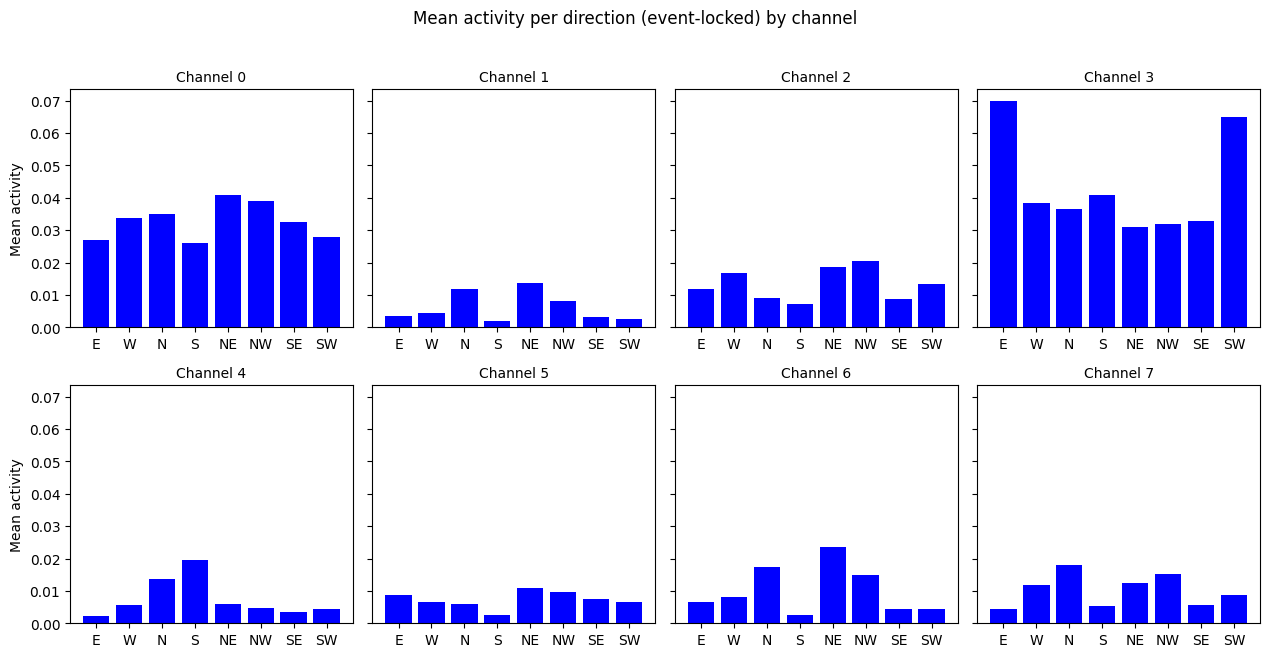

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes:
#   directions: dict[str -> array-like of shape (n_trials, n_channels)]
#   direction_names: dict[str -> pretty label for each key in `directions`]

# pick a consistent order for directions (use direction_names order if provided)
order = [k for k in direction_names.keys() if k in directions]
if not order:
    order = sorted(directions.keys())

labels = [direction_names.get(k, k) for k in order]
num_dirs = len(order)
num_channels = 8  # plot first 8

# precompute mean activity per (channel, direction)
means = np.zeros((num_channels, num_dirs), dtype=float)
for j, key in enumerate(order):
    A = np.asarray(directions[key])  # shape (n_trials, n_channels)
    for ch in range(num_channels):
        means[ch, j] = A[:, ch].mean()

# plot grid
rows, cols = 2, 4
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*3.2), sharey=True)

for ch in range(num_channels):
    ax = axes.flat[ch]
    ax.bar(np.arange(num_dirs), means[ch], color="b")
    ax.set_title(f"Channel {ch}", fontsize=10)
    ax.set_xticks(np.arange(num_dirs))
    ax.set_xticklabels(labels, rotation=0)
    if ch % cols == 0:
        ax.set_ylabel("Mean activity")

fig.suptitle("Mean activity per direction (event-locked) by channel", y=1.02)
fig.tight_layout()
plt.show()

In [97]:
import numpy as np

def circular_com_1d(weights, L):
    """Circular center-of-mass over a 1D ring of length L."""
    # indices -> angles on [0, 2π)
    idx = np.arange(L)
    theta = 2 * np.pi * idx / L
    w = weights.astype(float)
    wsum = w.sum()
    if wsum == 0:
        return np.nan  # or L/2 as a fallback
    C = (w * np.cos(theta)).sum() / wsum
    S = (w * np.sin(theta)).sum() / wsum
    theta_bar = np.arctan2(S, C) % (2 * np.pi)
    return (theta_bar / (2 * np.pi)) * L  # in index units [0, L)

def toroidal_com(frame):
    """
    frame: (H, W) intensity map on a torus.
    Returns (y_com, x_com) in index units with periodic CoM.
    """
    H, W = frame.shape
    # marginals along each axis
    wy = frame.sum(axis=1)   # length H
    wx = frame.sum(axis=0)   # length W
    y_com = circular_com_1d(wy, H)
    x_com = circular_com_1d(wx, W)
    return np.array([y_com, x_com], dtype=float)

def wrap_min_signed(delta_raw, L):
    """Minimal signed displacement on a ring of length L."""
    return ((delta_raw + L/2) % L) - L/2

def toroidal_trajectory(tensor):
    """
    tensor: (T, H, W)
    Returns CoM per frame with toroidal CoM: positions shape (T, 2) as (y, x).
    """
    T, H, W = tensor.shape
    pos = np.empty((T, 2), dtype=float)
    for t in range(T):
        pos[t] = toroidal_com(tensor[t])
    return pos  # CoM in index coords

def toroidal_net_displacement(tensor):
    """
    Robust net displacement integrating minimal periodic steps.
    Returns: net_disp (Δy, Δx), unit_direction (2,), and per-step displacements.
    """
    T, H, W = tensor.shape
    pos = toroidal_trajectory(tensor)  # (T, 2)
    d_raw = np.diff(pos, axis=0)       # (T-1, 2)
    dy = wrap_min_signed(d_raw[:, 0], H)
    dx = wrap_min_signed(d_raw[:, 1], W)
    disp_steps = np.stack([dy, dx], axis=1)
    net_disp = disp_steps.sum(axis=0)
    norm = np.linalg.norm(net_disp)
    unit_dir = net_disp / norm if norm > 0 else np.array([np.nan, np.nan])
    return net_disp, unit_dir, disp_steps


In [132]:
# record activations
from scipy.ndimage import center_of_mass
label_accuracies = []
integrated_directions = []
with torch.no_grad():
    sample_idx = 0
    for batch_inputs, labels in tqdm(data_loader):
        batch_inputs = np.array(batch_inputs)
        direction
        for sample, label in zip(batch_inputs, labels):
            net_disp, unit_dir, disp_steps = toroidal_net_displacement(sample[:, 0])
            if unit_dir[1] > 0:
                integrated_directions.append(0)
            else:
                integrated_directions.append(1)
            
            if label == 0 or label == 1:
                if int(label) == integrated_directions[-1]:
                    label_accuracies.append(1)
                else:
                    label_accuracies.append(0)

  0%|          | 0/125 [00:00<?, ?it/s]/tmp/ipykernel_3953722/252560034.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  batch_inputs = np.array(batch_inputs)
100%|██████████| 125/125 [15:00<00:00,  7.21s/it]


In [138]:
# # record decisions
model_decisions = []
classifier.to(device)
for batch_inputs, label in tqdm(data_loader):
    # input: (batch_size, channels, H, W)
    batch_size = batch_inputs.shape[0]
    batch_inputs = batch_inputs.to(device)
    pred = classifier(batch_inputs)
    model_decisions.extend(torch.argmax(pred, dim=-1).detach().tolist())
model_decisions = np.array(model_decisions)

  0%|          | 0/125 [00:05<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 256.00 MiB. GPU 0 has a total capacity of 79.14 GiB of which 94.75 MiB is free. Including non-PyTorch memory, this process has 79.02 GiB memory in use. Of the allocated memory 61.76 GiB is allocated by PyTorch, and 16.77 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [125]:
accuracies = []
for intg_dir, model_decision in zip(integrated_directions, model_decisions):
    if model_decision == 0 or model_decision == 1:
        if intg_dir == model_decision:
            accuracies.append(1)
        else:
            accuracies.append(0)

In [129]:
np.sum(accuracies)/len(accuracies)

np.float64(0.5093212933294494)

In [127]:
len(accuracies)

6866